In [59]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [60]:
sales_df=pd.read_csv('sales_data.csv')

In [61]:
sales_df.head()

,AdvertisingBudget,StoreSize,NumEmployees,Sales
0,25795,2167,15,78355
1,10860,1952,20,71429
2,48158,2827,20,112804
3,54732,2295,5,98570
4,21284,1962,13,74495


In [62]:
sales_df.drop(['NumEmployees'],axis=1,inplace=True)

In [63]:
sales_df.corr()

,AdvertisingBudget,StoreSize,Sales
AdvertisingBudget,1.000000,0.084867,0.692749
StoreSize,0.084867,1.000000,0.656161
Sales,0.692749,0.656161,1.000000


In [89]:
import seaborn as sns

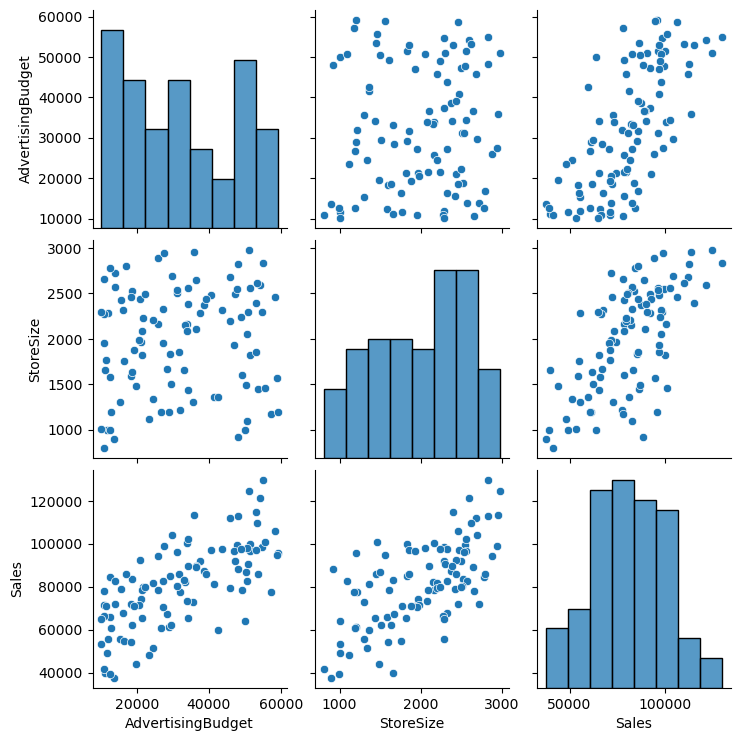

In [65]:
sns.pairplot(sales_df)
plt.show()

In [66]:
x=sales_df.iloc[:,:-1]
y=sales_df.iloc[:,-1]

In [67]:
x.head()

,AdvertisingBudget,StoreSize
0,25795,2167
1,10860,1952
2,48158,2827
3,54732,2295
4,21284,1962


In [68]:
from sklearn.model_selection import train_test_split

In [69]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=44)

In [70]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()


In [71]:
scalar.fit_transform(x_train)
scalar.fit_transform(x_test)

array([[-0.65902653,  0.05173521],
       [ 1.45762763,  1.48602835],
       [-0.17810042, -0.47333351],
       [-0.78572874, -0.53204727],
       [ 0.58044897,  0.88211544],
       [ 1.37129018, -0.84574647],
       [ 0.97818053,  0.91566616],
       [-0.14660974, -1.26680796],
       [ 1.23947304, -0.20828285],
       [-1.07093198,  1.03309367],
       [-0.78831702,  0.85359734],
       [-0.13576364, -0.19150749],
       [-1.07419813,  1.29311173],
       [-0.890369  ,  1.41892691],
       [-0.23128331,  1.66720222],
       [-1.15566716, -1.60231513],
       [ 1.71904338, -1.26177536],
       [-1.23584206, -0.48507626],
       [-0.48709113, -1.40101083],
       [-0.71664646, -0.78703271],
       [ 1.1755673 , -0.76186968],
       [ 1.25007264,  1.01464078],
       [-0.92783736,  0.62041985],
       [ 1.50594209, -0.82058343],
       [-0.79423308, -0.5991487 ]])

In [72]:
from sklearn.linear_model import LinearRegression
Regression = LinearRegression()

In [73]:
Regression.fit(x_train,y_train)

LinearRegression()

In [74]:
y_pred = Regression.predict(x_test)

In [75]:
from sklearn.metrics import mean_squared_error ,mean_absolute_error

In [76]:
mse=mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse= np.sqrt(mse)

In [77]:
from sklearn.metrics import r2_score

In [78]:
score= r2_score(y_test,y_pred)

In [79]:
adj_r2=1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

In [80]:
adj_r2

0.8088918019721152

In [81]:
residul=y_test-y_pred

In [82]:
residul.head()

42    -1060.660883
54    14531.914245
27    -4933.614081
93    -2190.262257
39     -701.361382
Name: Sales, dtype: float64

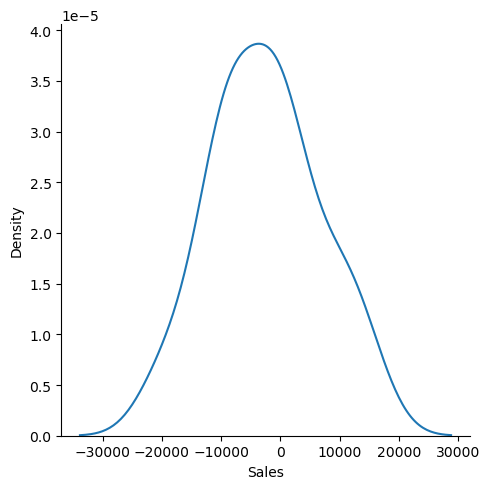

In [83]:
sns.displot(residul,kind='kde')
plt.show()

In [84]:
import statsmodels.api as sm

In [87]:
model=sm.OLS(y_train,x_train).fit()

In [88]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                  Sales   R-squared (uncentered):                   0.989
Model:                            OLS   Adj. R-squared (uncentered):              0.989
Method:                 Least Squares   F-statistic:                              3423.
Date:                Fri, 10 Oct 2025   Prob (F-statistic):                    7.06e-73
Time:                        18:43:27   Log-Likelihood:                         -786.21
No. Observations:                  75   AIC:                                      1576.
Df Residuals:                      73   BIC:                                      1581.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------